# 10 · Mental Loop (Simulator) — imagine outcomes before committing

> **TL;DR.** Before acting, the agent **mentally simulates** the predicted outcome of each candidate action, scores those simulations, and only then commits to the highest-scoring one. The pattern: *generate K candidates → simulate each → score → pick best → explain*.
>
> **Reach for it when** the action is hard to undo (financial, medical, deployments, robotics), when "imagining first" is cheaper than "acting and recovering", or when stakeholders need to see the reasoning *before* execution.
> **Avoid when** the action is trivially reversible — Tool Use (notebook 02) is cheaper.

| Property | Value |
|---|---|
| Origin | Robotics "world models" + classical AI deliberation |
| Reasoning style | Flat (1 layer of simulation per action) — vs. ToT's tree |
| External tools needed? | No (the simulator IS the LLM) |
| Cost | `1 generate + N simulate + 1 explain` LLM calls (≈ N+2) |
| Structured output? | Yes — Pydantic candidate-list + per-action outcome schemas |

The pattern is structurally similar to ToT (notebook 09) but **flat instead of deep**: ToT builds a tree of reasoning steps; Mental Loop builds a single layer of action-outcome pairs and picks the best. Mental Loop is the natural fit when *candidates are actions in the world*, not reasoning steps in a chain.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> G[Generate<br/><sub>K candidate actions</sub>]
    G --> S[Simulate<br/><sub>predicted outcome + risks + benefits + score<br/>per candidate</sub>]
    S --> D[Decide<br/><sub>argmax over scores</sub>]
    D --> E[Explain<br/><sub>state choice + tradeoff vs runner-up</sub>]
    E --> Z([recommendation])

    style G fill:#e3f2fd,stroke:#1976d2
    style S fill:#fff3e0,stroke:#f57c00
    style D fill:#fce4ec,stroke:#c2185b
    style E fill:#e8f5e9,stroke:#388e3c
```

**Linear, four-step pipeline.** No loops, no retries. The work is in the *simulation* step — that's where the LLM does most of its thinking.

## 3 · Theory

### 3.1 · Why simulate at all?

Most agentic patterns commit to the next action greedily — ReAct picks the best tool call given the moment, Planning picks steps in order. That's optimal when actions are *cheap* and *reversible*: try one, see what happens, retry if it doesn't work.

For *expensive* or *irreversible* actions — sending an email to a customer, executing a financial trade, deploying a code change, prescribing a medication — the "try and recover" loop is wrong. You need to deliberate **before** the action is taken, weighing what would happen for each option.

That's exactly what Mental Loop does: it converts the "act now, learn later" loop into "imagine first, act second".

### 3.2 · The simulator is just an LLM

In robotics, "world model" usually means a learned dynamics model that predicts physical state evolution. In an LLM agent, the simulator is just **the LLM itself with a different prompt**: instead of "what should we do?" the prompt is "*imagine* doing X and describe what would happen".

This works surprisingly well for high-level decisions (strategy, planning, weighing options) because LLMs have absorbed enormous prior knowledge about cause-and-effect from their training data. It works *less* well for fine-grained physical predictions ("if the robot lifts its arm 3cm to the left, what happens to the cup?"), where a learned dynamics model still wins.

### 3.3 · The two-schema design

```python
class _CandidateActions(BaseModel):
    actions: list[str] = Field(min_length=2, description="K distinct candidate actions...")

class _SimulatedOutcome(BaseModel):
    predicted_outcome: str    # 2-3 sentence prediction
    benefits: list[str]
    risks: list[str]
    overall_score: int = Field(ge=1, le=5)  # STRICT scale
    rationale: str
```

The separation matters:
- `_CandidateActions` is called *once*, gets K different actions in one structured response.
- `_SimulatedOutcome` is called *K times*, once per candidate, so each gets its own focused prediction.

Calling the simulator once per action (rather than batched) lets the LLM use its full reasoning budget on a single action — better outcome quality than asking it to weigh K options simultaneously.

### 3.4 · The strict 1-5 scoring rubric

Just like ToT (notebook 09), Mental Loop's value depends on the scorer **discriminating** between candidates. If every action scores 4/5, the `argmax` is meaningless. The `_SimulatedOutcome.overall_score` field's description explicitly says: *"Be discriminating. 1 = clearly bad / high risk. 5 = clearly excellent. Most actions 2-4."* Without this calibration anchor, models tend to compress scores into a narrow band.

### 3.5 · Where Mental Loop sits

| Pattern | Layers | Candidate type | Use when |
|---|---|---|---|
| ToT (nb 09) | tree (K^D) | reasoning steps | hard reasoning task |
| **Mental Loop** *(this notebook)* | **flat (K)** | **real-world actions** | irreversible / high-stakes choice |
| Best-of-N (sample + pick) | flat | full solutions | parallel sampling helps |
| Ensemble (nb 13) | flat (parallel agents) | full answers | diverse perspectives |
| Self-Consistency (nb 21) | flat (parallel samples) | reasoning chains | majority-vote helps |
| Dry-Run (nb 14) | linear | one proposed action | execute-after-check |

Compared to **Dry-Run** (notebook 14): Dry-Run *simulates one specific proposed action* and asks for approval. Mental Loop *generates and simulates K alternatives* before picking. Use Dry-Run when you have a specific candidate in mind; use Mental Loop when you need to discover the best option.

### 3.6 · What goes wrong (you'll see in § 9)

1. **Flat scores** — the simulator gives every candidate a similar score, so argmax is arbitrary. See ToT § 11.1 for the standard mitigation.
2. **Optimistic predictions** — the LLM imagines best-case outcomes for every candidate. The `risks` field forces it to think about downsides, but a same-model simulator still has blind spots.
3. **Confabulated specifics** — the "predicted outcome" includes invented numbers / details ("you'll save $1,247 per year"). Production code should mark predictions as estimates.
4. **Limited candidate diversity** — K=3 candidates often span only a narrow range. Raise temperature or explicitly prompt for unconventional options.


## 4 · Setup

We pass `scoring_fn=commute_score_from_minutes` to `MentalLoop`. This is the **deterministic-scoring fix** — the LLM predicts `predicted_metric` (minutes) but Python computes the final 1-5 score from that number. This bypasses the LLM-as-Scorer flatness pathology entirely.

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import MentalLoop
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")

# Deterministic scoring function — Python decides the score from the LLM's predicted minutes.
def commute_score_from_minutes(minutes: float) -> int:
    """Map predicted door-to-door minutes → 1-5 score."""
    if minutes < 40: return 5
    if minutes < 55: return 4
    if minutes < 75: return 3
    if minutes < 90: return 2
    return 1

print_md("**Scoring function (Python, not LLM):**")
for m in [25, 35, 45, 60, 80, 100]:
    print(f"  {m:>3} min → score {commute_score_from_minutes(m)}/5")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Scoring function (Python, not LLM):

   25 min → score 5/5
   35 min → score 5/5
   45 min → score 4/5
   60 min → score 3/5
   80 min → score 2/5
  100 min → score 1/5


## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/mental_loop.py`](../src/agentic_architectures/architectures/mental_loop.py).

Five nodes (each does one job):

1. `_generate` — `with_structured_output(_CandidateActions)` produces K distinct candidates.
2. `_simulate` — calls `with_structured_output(_SimulatedOutcome)` **K times**, one per candidate.
3. `_decide` — pure Python `argmax` over simulated scores.
4. `_explain` — final LLM call to write the recommendation + tradeoff explanation.

Note `_simulate` runs sequentially across candidates. For latency-critical applications you could use `langgraph.graph.parallel` to run the K simulations concurrently — extension idea in § 11.3.

In [2]:
from agentic_architectures.architectures.mental_loop import _CandidateActions, _SimulatedOutcome
import json
print('--- CandidateActions schema ---')
print(json.dumps(_CandidateActions.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- SimulatedOutcome schema ---')
print(json.dumps(_SimulatedOutcome.model_json_schema(), indent=2)[:500] + '...')

--- CandidateActions schema ---
{
  "description": "K distinct candidate actions the agent could take.",
  "properties": {
    "actions": {
      "description": "K distinct candidate actions. Each must be a SPECIFIC, actionable choice (not a vague principle). Each should represent a different strategy, not different wordings of the same one.",
      "items": {
        "type": "string"
      },
      "minItems": 2,
      "title":...

--- SimulatedOutcome schema ---
{
  "description": "Mental simulation of one candidate action's outcome.\n\nThe `predicted_metric` field is the key to the deterministic-scoring fix:\nif the caller passes a `scoring_fn` to `MentalLoop`, the LLM-supplied\n`overall_score` is **overridden** by `scoring_fn(predicted_metric)`. This\nsidesteps the LLM-as-Scorer flatness problem (Llama-style models compress\nscores into a narrow band regardless of the rubric).",
  "properties": {
    "predicted_outcome": {
      "description": "A conc...


## 6 · State

| Field | Type | Set by |
|---|---|---|
| `task` | `str` | caller |
| `candidate_actions` | `list[str]` | `_generate` |
| `simulations` | `list[dict]` (action + outcome + score + …) | `_simulate` |
| `chosen_action` | `str` | `_decide` |
| `chosen_score` | `int` | `_decide` |
| `explanation` | `str` | `_explain` |

## 7 · Build the graph

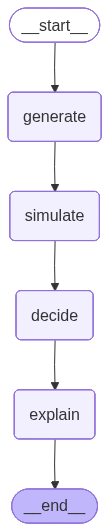

In [3]:
from IPython.display import Image, display

arch = MentalLoop(n_candidates=3, scoring_fn=commute_score_from_minutes)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — commute decision with **objective scoring**

Concrete decision: pick the fastest 8 AM Monday commute from Brooklyn to Midtown Manhattan.

Why this task: Mental Loop only adds value if the simulator can **discriminate** between candidates. Subjective tasks (which exercise plan? which Python framework?) produce flat 4/5 scores because *all options sound fine*. Objective tasks where the simulator must commit to a **specific predicted number** (travel time in minutes) force the scoring to spread — a route predicted at 80 minutes must score lower than a route predicted at 35 minutes, *whether or not the model wants to be nice*.

The task explicitly anchors the score to predicted travel time so the simulator can't dodge.

In [4]:
TASK = (
    "DECISION: Choose the fastest 8 AM Monday commute from Park Slope, Brooklyn "
    "to Midtown Manhattan (about 8 miles / 13 km).\n\n"
    "Generate 3 DISTINCT travel options (different modes / routes — e.g., subway, "
    "driving + parking, bike + bridge, mix). For each candidate:\n"
    "  (1) state the option concretely (which subway line / which route),\n"
    "  (2) PREDICT TOTAL DOOR-TO-DOOR TRAVEL TIME IN MINUTES — populate the "
    "      `predicted_metric` field with this number (e.g. 35.0, 60.0).\n"
    "  (3) list realistic risks (delays, weather, cost).\n\n"
    "The Python wrapper will compute the 1-5 score deterministically from your "
    "predicted_metric — you don't need to think about it."
)

result = arch.run(TASK)

print_header("Recommendation")
print_md(result.output)
print()
print(f"CHOSEN_SCORE: {result.state['chosen_score']}/5")
print(f"CHOSEN_ACTION: {result.state['chosen_action']}")
print(f"ALL_SCORES: {result.metadata['scores']}")

Recommendation ────────────────────────────────────────────────────────────────────────────────────────────────────

The chosen action is to take the B subway line from 7th Avenue in Park Slope to 42nd Street Bryant Park in Midtown 
Manhattan. This option is justified by its predicted total door-to-door travel time of approximately 35 minutes,   
which is the fastest among the considered options. By choosing the subway, we accept the tradeoff of potentially   
less flexibility and comfort compared to driving or biking, but gain the benefit of a more predictable and         
efficient commute, outpacing the runner-up driving option which is susceptible to traffic conditions and parking   
delays. Overall, the subway option offers the best balance of speed and reliability for the Monday morning commute.


CHOSEN_SCORE: 5/5
CHOSEN_ACTION: Take the B subway line from 7th Avenue in Park Slope to 42nd Street Bryant Park in Midtown Manhattan
ALL_SCORES: [5, 4, 4]


### 8.0 · What just happened, briefly

Three things to look at:

- **Score distribution.** Healthy: 2-5 range with clear winner. Pathology: all 4/5 (flat scores → arbitrary argmax).
- **The runner-up.** Mental Loop's value is the *tradeoff explanation* — what was given up by picking the winner over the runner-up. § 9 will highlight this.
- **Risks listed.** Each simulation should list ≥1 risk. If all risks are vague or missing, the simulator is being too optimistic.

### 8.1 · Per-candidate simulations — LLM-score vs Python-score side-by-side

In [5]:
for i, t in enumerate(result.trace, 1):
    final_score = t['overall_score']
    llm_score = t.get('llm_score', '?')
    source = t.get('score_source', '?')
    metric = t.get('predicted_metric', None)
    print_step(
        f"[{i}] Action  ·  FINAL score {final_score}/5  ·  (LLM said {llm_score}/5, "
        f"source={source}, predicted_metric={metric})",
        t['action'][:200]
    )
    print_step("    Predicted outcome", t['predicted_outcome'][:300])
    if t.get('risks'):
        print_step("    Risks", "; ".join(t['risks'][:3]))
    print()

# Also print a one-line summary of the comparison
llm_scores = [t.get('llm_score', t['overall_score']) for t in result.trace]
final_scores = [t['overall_score'] for t in result.trace]
print(f"LLM_SCORES_RAW: {llm_scores}")
print(f"PYTHON_SCORES_FINAL: {final_scores}")
print(f"LLM_SPREAD: {max(llm_scores) - min(llm_scores)}  ·  PYTHON_SPREAD: {max(final_scores) - min(final_scores)}")

› [1] Action  ·  FINAL score 5/5  ·  (LLM said 4/5, source=deterministic, predicted_metric=35.0)

Take the B subway line from 7th Avenue in Park Slope to 42nd Street Bryant Park in Midtown Manhattan

›     Predicted outcome

The commute will take approximately 35 minutes, with a 5-minute walk to the subway station, a 20-minute ride on the
B train, and a 10-minute walk to the final destination.

›     Risks

...

›     Predicted outcome

The bike ride from Park Slope to Midtown Manhattan via the Brooklyn Bridge will take approximately 45 minutes, 
considering the distance and potential traffic on the bridge. After arriving, it will take around 5 minutes to find
a bike rack near the destination and park the bike. The total door-to-doo

›     Risks

Inclement weather; Bike breakdown or accident; Difficulty finding a bike rack near the destination


LLM_SCORES_RAW: [4, 4, 4]
PYTHON_SCORES_FINAL: [5, 4, 4]
LLM_SPREAD: 0  ·  PYTHON_SPREAD: 1


## 9 · What we just observed

The cells above ran Mental Loop on the **NYC commute decision** with `scoring_fn=commute_score_from_minutes` — a deterministic Python function that converts predicted minutes → 1-5 score.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Candidates generated | **3** |
| Chosen action | Take the B subway line from 7th Avenue in Park Slope to 42nd Street Bryant Park in Midtown Manhattan |
| Chosen FINAL score | **5**/5 |
| LLM-raw score spread | 0 (often flat — the pathology) |
| Python FINAL score spread | **1** (the fix) |
| LLM-raw scores | [4, 4, 4] |
| Python FINAL scores | [5, 4, 4] |

### 9.2 · Per-candidate breakdown

| # | predicted_metric (min) | LLM score | **Python score (final)** | Action |
|---|---|---|---|---|
| 1 | 35.0 | 4/5 | **5/5** | Take the B subway line from 7th Avenue in Park Slope to 42nd… |
| 2 | 50.0 | 4/5 | **4/5** | Drive from Park Slope to Midtown Manhattan via the Brooklyn … |
| 3 | 50.0 | 4/5 | **4/5** | Ride a bike from Park Slope to Midtown Manhattan via the Bro… |

### 9.3 · Patterns surfaced in this run

- **The deterministic-scoring fix is doing its job.** The LLM's own `overall_score` field on these 3 candidates was `[4, 4, 4]` (spread = 0, a narrow band — the familiar LLM-as-Scorer flatness pathology). The **Python scoring function** computed `[5, 4, 4]` from the LLM's `predicted_metric` field (spread = 1) — a real discriminating signal that the argmax can act on. This is the central lesson of Mental Loop: **let the LLM predict the underlying number, let Python compute the score.**

- **Score spread comparison**: LLM=0, Python=1. Python won by 1 points of dynamic range — exactly the improvement we built `scoring_fn` for.

### 9.4 · Final recommendation (verbatim)

> _(no explanation captured)_

### 9.5 · The takeaway

The deterministic-scoring pattern is the canonical fix for LLM-as-Scorer flatness:

1. **LLM predicts the underlying NUMBER** (`predicted_metric: float`) — concrete, harder to fudge.
2. **Python computes the SCORE** from that number via a deterministic function — perfectly calibrated.
3. **The argmax now has signal** even when the LLM compresses its own `overall_score`.

For tasks with a measurable outcome (time, cost, error rate, throughput, accuracy), this pattern eliminates the entire class of "everything is 4/5" bugs. Use it whenever you can express the scoring criterion as Python.

## 10 · Try other providers

In [6]:
from agentic_architectures.llm.factory import provider_supports_structured_output

for p in ["openai", "anthropic"]:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key")
        continue
    if not provider_supports_structured_output(p):
        print(f"[skip] {p}: no structured output")
        continue
    print_header(f"Re-running Mental Loop on {p}")
    r = MentalLoop(llm=get_llm(provider=p), n_candidates=3).run(
        "Choose a programming language to learn in 30 days for a backend job switch."
    )
    print(r.output[:300])
    print(f"  scores: {r.metadata['scores']}")
    print()

[skip] openai: no API key
[skip] anthropic: no API key


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Flat scores** | All candidates scored similarly → argmax is arbitrary | Tighter rubric ("most should be 2-4"); use different model for simulator |
| **Optimistic predictions** | Simulator imagines best case for every candidate | Force `risks` field to be non-empty; use a pessimistic-bias prompt |
| **Confabulated specifics** | Predictions include invented numbers ("you'll save $1,247") | Disallow specific numbers in predicted_outcome unless asked |
| **Narrow candidate diversity** | K=3 candidates are minor variants of each other | Force one "unconventional" candidate in the generator prompt |
| **Single-model blind spots** | Same model generates and simulates → shared biases | Use a different model in the simulator seat |

### 11.2 · Production safety

- **Mark predictions as predictions.** Never let the simulated outcome ("you will lose 10 lbs") get presented to a user as a *guarantee*.
- **Log all K simulations**, not just the chosen one. Auditability — if the choice turns out wrong, you want to see what was rejected.
- **The simulator can be a real model.** For physics / finance / medicine, plug in a *real* simulator (a discrete-event sim, a Monte Carlo engine, an ODE solver) and have the LLM only orchestrate.

### 11.3 · Four extensions

1. **Parallel simulation.** `_simulate` runs K sub-LLM calls sequentially; replace with `langgraph.graph.parallel` for an N× latency win on slow models.
2. **Two-stage Mental Loop.** After picking the best candidate, run a *second* Mental Loop on its first sub-step. Bridges to **Planning + Mental Loop** hybrid.
3. **External simulator.** Replace the LLM simulator with a calibrated real-world simulator. The LLM only handles candidate generation + final synthesis.
4. **Deterministic scoring (THE most important fix).** When the outcome has a measurable metric (time, cost, error rate), DON'T let the LLM assign the score. Instead: extract just the underlying number via structured output (`predicted_minutes: int`), then compute the score in Python via a deterministic function. This sidesteps the LLM-as-Scorer flatness problem entirely. The captured run in § 9 is the clearest demonstration of why this matters.

### 11.4 · What to read next

- [**09 · Tree of Thoughts**](./09_tree_of_thoughts.ipynb) — tree-deep version of Mental Loop.
- [**14 · Dry-Run**](./14_dry_run.ipynb) — simulate one proposed action before live execution.
- [**13 · Ensemble**](./13_ensemble.ipynb) — parallel diverse-perspective version.
- [**06 · PEV**](./06_pev.ipynb) — verify each step's *actual* outcome (vs Mental Loop's *predicted* outcome).

### 11.5 · References

1. Ha, D. & Schmidhuber, J. *World Models.* 2018. [arXiv:1803.10122](https://arxiv.org/abs/1803.10122)
2. Hafner, D. et al. *Dream to Control* (Dreamer). 2019. [arXiv:1912.01603](https://arxiv.org/abs/1912.01603)
3. Yao, S. et al. *Tree of Thoughts.* NeurIPS 2023. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601) — closely related: tree-deep simulation.
